# 🎬 Analyse exploratoire du dataset MovieLens

## 📌 Objectif
Ce notebook a pour but d'explorer les données du dataset **MovieLens Small**, qui contient des informations sur des films, des évaluations données par des utilisateurs, des tags et des liens vers d'autres bases de films.

### 🔍 Étapes prévues :
- Charger les fichiers CSV
- Explorer les structures des données
- Vérifier la qualité des données (valeurs manquantes, types, etc.)
- Comprendre les relations entre les fichiers
- Lister les genres de films distincts


In [112]:
# 📦 Imports des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📋 Config d'affichage
pd.set_option('display.max_columns', None)


In [113]:
# 📂 Chargement des fichiers CSV
movies = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings.csv')
tags = pd.read_csv('../data/raw/tags.csv')
links = pd.read_csv('../data/raw/links.csv')


## 👀 Aperçu des données
Nous observons les premières lignes de chaque fichier pour comprendre leur structure.


In [114]:
# 👁️ Affichage des premières lignes
print("🎬 movies.csv")
display(movies.head())

print("⭐ ratings.csv")
display(ratings.head())

print("🏷️ tags.csv")
display(tags.head())

print("🔗 links.csv")
display(links.head())


🎬 movies.csv


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


⭐ ratings.csv


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


🏷️ tags.csv


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


🔗 links.csv


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


## 📏 Dimensions et types de données


In [115]:
# 🔍 Dimensions
print("Movies :", movies.shape)
print("Ratings :", ratings.shape)
print("Tags :", tags.shape)
print("Links :", links.shape)

# ℹ️ Informations sur les colonnes
print("\nMovies:")
movies.info()
print("\nRatings:")
ratings.info()
print("\nTags:")
tags.info()
print("\nLinks:")
links.info()


Movies : (9742, 3)
Ratings : (100836, 4)
Tags : (3683, 4)
Links : (9742, 3)

Movies:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

Ratings:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Tags:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
--- 

## 🧹 Nettoyage des doublons avant modélisation

In [116]:
movies = movies.drop_duplicates(subset=['movieId'])
ratings = ratings.drop_duplicates(subset=['userId', 'movieId', 'timestamp'])
tags = tags.drop_duplicates(subset=['userId', 'movieId', 'timestamp'])
links = links.drop_duplicates(subset=['movieId'])


## ❓ Analyse des valeurs manquantes


In [117]:
# 🔎 Vérification des valeurs nulles
print("Movies :\n", movies.isnull().sum())
print("\nRatings :\n", ratings.isnull().sum())
print("\nTags :\n", tags.isnull().sum())
print("\nLinks :\n", links.isnull().sum())


Movies :
 movieId    0
title      0
genres     0
dtype: int64

Ratings :
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Tags :
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Links :
 movieId    0
imdbId     0
tmdbId     8
dtype: int64


## 🎭 Exploration des genres de films


In [118]:
# 🎬 Extraction des genres distincts
genres_exploded = movies['genres'].str.split('|').explode()
genres_uniques = genres_exploded.unique()

print("Genres distincts :", genres_uniques)
print("Nombre de genres :", len(genres_uniques))


Genres distincts : ['Adventure' 'Animation' 'Children' 'Comedy' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Mystery' 'Sci-Fi' 'War' 'Musical'
 'Documentary' 'IMAX' 'Western' 'Film-Noir' '(no genres listed)']
Nombre de genres : 20


## 📊 Visualisation : Nombre de films par genre


C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\1646711825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=genre_counts, x='genre', y='count', palette='pastel')
C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\1646711825.py:12: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\1646711825.py:12: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyp

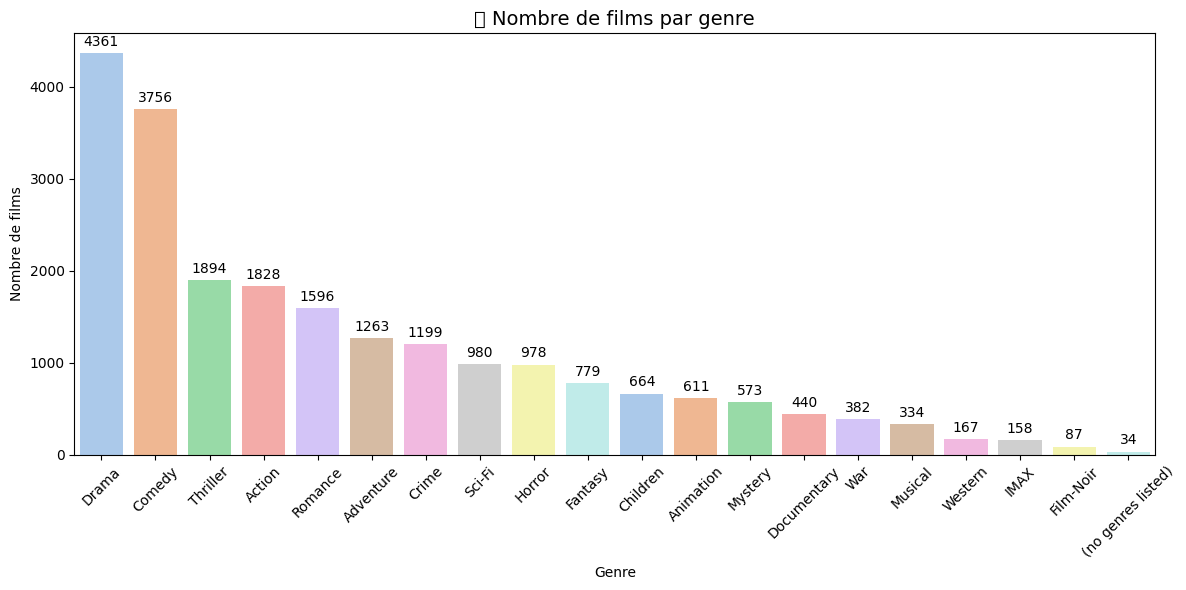

In [119]:
plt.figure(figsize=(12,6))
ax = sns.barplot(data=genre_counts, x='genre', y='count', palette='pastel')

# Annotation de toutes les barres avec pandas
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('🎭 Nombre de films par genre', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Nombre de films')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## ⭐ Visualisation 1 : Distribution des notes

Affichons la distribution des notes données par les utilisateurs.  
Les notes vont de 0.5 à 5 par pas de 0.5.


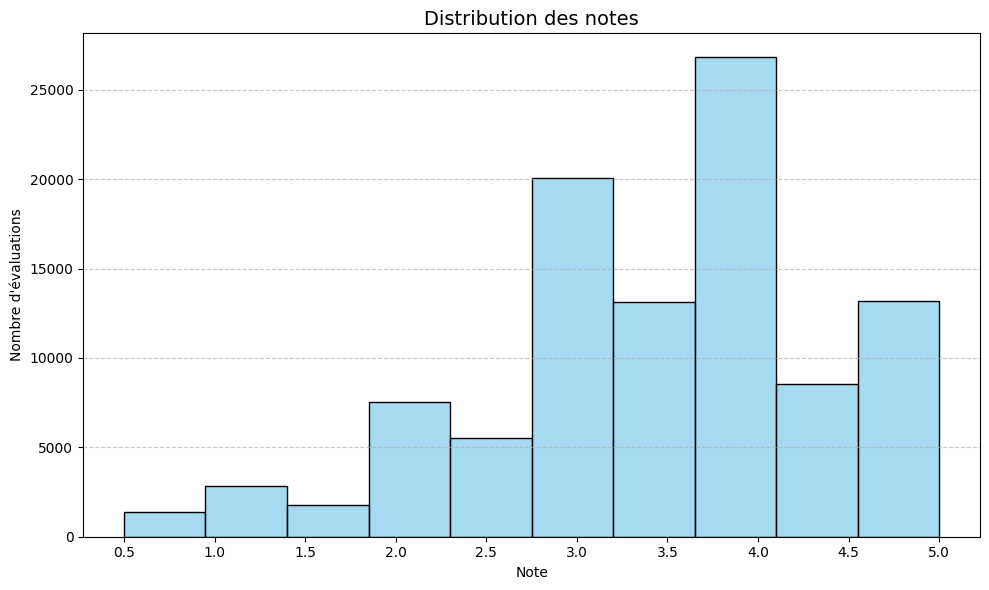

In [120]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=10, kde=False, color='skyblue')

plt.title('Distribution des notes', fontsize=14)
plt.xlabel('Note')
plt.ylabel('Nombre d\'évaluations')
plt.xticks(ticks=np.arange(0.5, 5.5, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 📈 Visualisation 2 : Nombre de notations par année

Le champ `timestamp` a été converti pour permettre une analyse temporelle.  
Voyons l’évolution du volume de notations au fil des années.


C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\3934781039.py:11: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


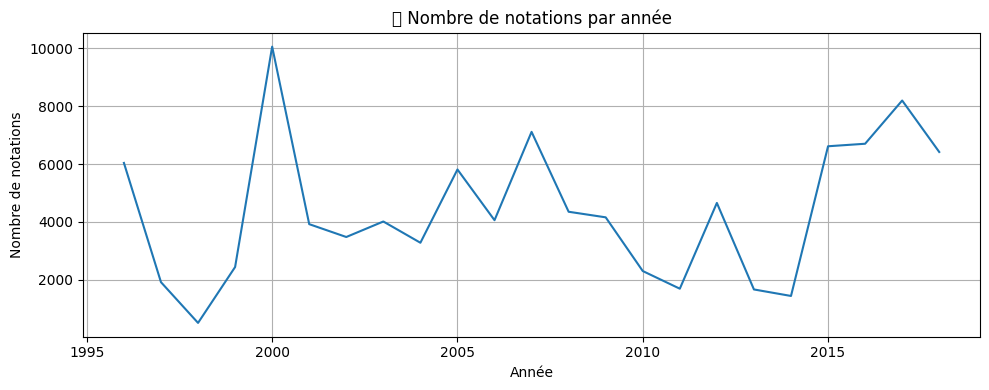

In [121]:
# Conversion du timestamp 
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['date'].dt.year

plt.figure(figsize=(10,4))
ratings['year'].value_counts().sort_index().plot()
plt.title("📈 Nombre de notations par année")
plt.xlabel("Année")
plt.ylabel("Nombre de notations")
plt.grid(True)
plt.tight_layout()
plt.show()


## 📦 Visualisation 3 : Note moyenne par genre principal

Chaque film est associé à plusieurs genres.  
Pour simplifier, nous utilisons **le premier genre** comme genre principal pour une première analyse.


C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\1913878325.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_avg, x='rating', y='main_genre', palette='rocket')
C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\1913878325.py:15: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\1913878325.py:15: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) mi

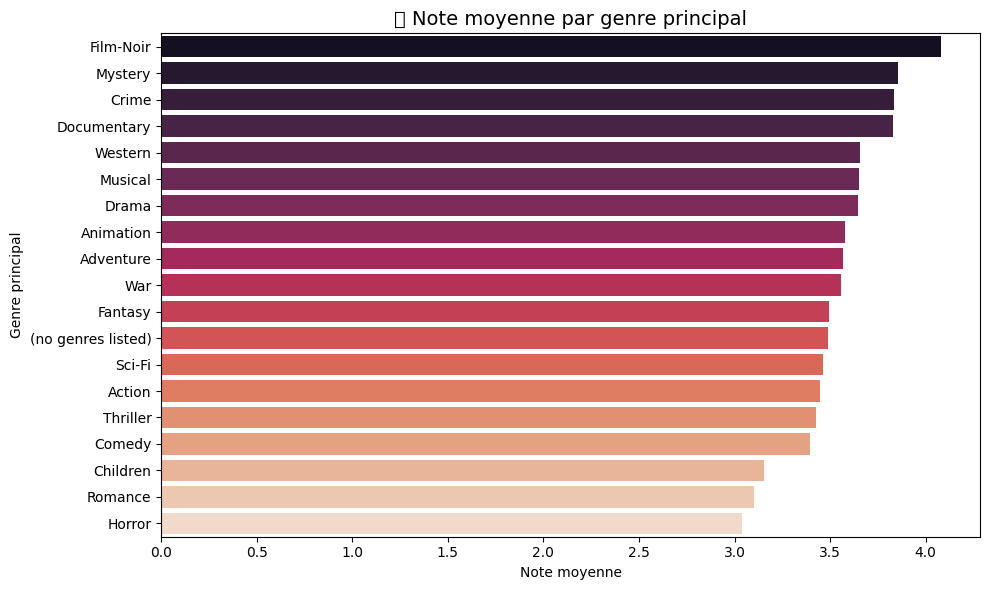

In [122]:
# Recalcul si besoin
movies['main_genre'] = movies['genres'].str.split('|').str[0]
ratings_with_genre = ratings.merge(movies[['movieId', 'main_genre']], on='movieId')

# Moyenne par genre
genre_avg = ratings_with_genre.groupby('main_genre')['rating'].mean().sort_values(ascending=False).reset_index()

# 📊 Barplot horizontal avec palette vive
plt.figure(figsize=(10,6))
sns.barplot(data=genre_avg, x='rating', y='main_genre', palette='rocket')  

plt.title("📦 Note moyenne par genre principal", fontsize=14)
plt.xlabel("Note moyenne")
plt.ylabel("Genre principal")
plt.tight_layout()
plt.show()


## 🔗 Corrélations exploratoires : année de sortie, note moyenne, nombre de notations

L'année de sortie d'un film n'est pas présente dans une colonne dédiée, mais est incluse dans le titre sous forme de texte, comme `"The Matrix (1999)"`.

Nous allons :
- Extraire cette année de sortie
- Calculer la note moyenne et le nombre de notations par film
- Observer s'il existe des tendances globales entre ces variables

> ⚠️ Cette analyse est exploratoire. Le dataset MovieLens reflète les notations d'une communauté d'utilisateurs sur une période donnée. Les corrélations doivent donc être interprétées avec prudence.


In [123]:
# Extraire l'année depuis le titre
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

# Calcul des stats par film
film_stats = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

# Fusion avec les métadonnées (année)
film_stats = film_stats.merge(movies[['movieId', 'year']], on='movieId')
film_stats.dropna(subset=['year'], inplace=True)  # on garde que les films dont l'année a pu être extraite
print(film_stats.head())

   movieId  avg_rating  rating_count    year
0        1    3.920930           215  1995.0
1        2    3.431818           110  1995.0
2        3    3.259615            52  1995.0
3        4    2.357143             7  1995.0
4        5    3.071429            49  1995.0


C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\3269925580.py:8: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


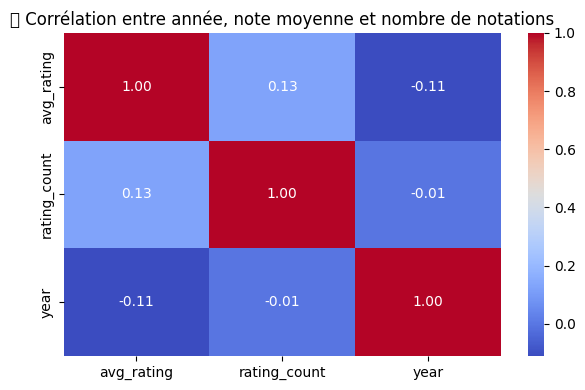

In [124]:
# Matrice de corrélation
corr_matrix = film_stats[['avg_rating', 'rating_count', 'year']].corr()

# Visualisation
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("🔗 Corrélation entre année, note moyenne et nombre de notations")
plt.tight_layout()
plt.show()


## 🧠 Interprétation

- La corrélation entre `year` et `rating_count` permet d'observer si les films récents sont plus notés (ce qui est souvent le cas).
- La corrélation entre `year` et `avg_rating` peut indiquer une tendance globale dans l'évaluation des films selon leur époque.
- Une faible ou négative corrélation peut montrer que les films anciens, même peu vus, sont souvent très bien notés (biais de nostalgie ?).

Ces résultats ne doivent pas être considérés comme des vérités absolues mais comme des **indices utiles** pour guider les prochaines analyses (ex. filtrage par années, pondération des notes, etc.).


## 📈 Scatterplot : Note moyenne en fonction de l'année de sortie

Ce graphique permet de visualiser chaque film individuellement :
- Sa note moyenne (`y`)
- Son année de sortie (`x`)
- Le **nombre de notations** (taille du point)

Cela permet de repérer les films très bien notés avec très peu de votes, ou à l'inverse très populaires.


C:\Users\Hammiche\AppData\Local\Temp\ipykernel_564\2755394085.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


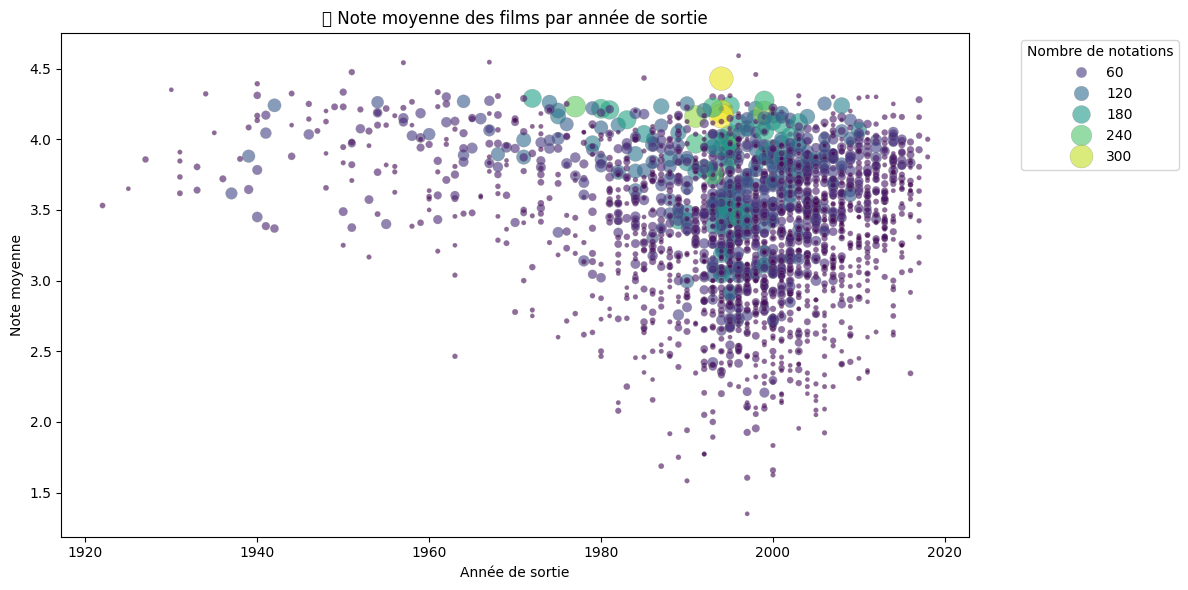

In [125]:
# On filtre pour exclure les films avec trop peu de votes (moins de 10 par exemple)
filtered_stats = film_stats[film_stats['rating_count'] >= 10]

plt.figure(figsize=(12,6))
scatter = sns.scatterplot(
    data=filtered_stats,
    x='year', 
    y='avg_rating',
    size='rating_count',
    sizes=(10, 300),         # taille minimale et maximale des points
    alpha=0.6,
    hue='rating_count',
    palette='viridis',
    edgecolor='grey'
)

plt.title("📈 Note moyenne des films par année de sortie")
plt.xlabel("Année de sortie")
plt.ylabel("Note moyenne")
plt.legend(title="Nombre de notations", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 🧠 Conclusion – Analyse visuelle des notes par année

Ce scatterplot met en évidence plusieurs éléments intéressants :

- 📊 Les films récents (après 2000) sont largement plus représentés dans les notations.
- ⭐ Certains films affichent des notes moyennes très élevées, mais n'ont été notés que par un petit nombre d'utilisateurs (points petits et isolés).
- 🎯 Une majorité de films ont des notes concentrées entre **3.0 et 4.0**, indépendamment de leur année de sortie.
- 🧨 Quelques outliers bien visibles mériteraient d'être examinés (films très anciens très bien notés ? ou artefacts de données ?)

> Ces observations nous invitent à approfondir l’analyse **par SQL** :
- Quels sont les **films les mieux notés avec au moins 100 notations** ?
- Quelle est la **note moyenne par genre et par période** ?
- Peut-on construire une **vue filtrée et propre des films significatifs** (avec seuils de qualité) ?
- Quels sont les **utilisateurs les plus actifs** et leur comportement de notation ?

> 💡 Observation :
> Un certain nombre de films n'ont été notés que quelques fois (souvent moins de 10 fois), ce qui peut fausser les statistiques.
>
> ⚠️ Cette information est utile pour la **modélisation SQL** : nous pourrons, dans une vue SQL dédiée, **filtrer les films les plus fiables** (ex. ceux ayant reçu au moins 50 ou 100 notations).


✅ Nous allons donc passer à la phase suivante : **création de la base PostgreSQL**, modélisation relationnelle, et insertion des données pour préparer les futures analyses croisées.


## 💾 Sauvegarde des versions nettoyées

Nous sauvegardons les fichiers nettoyés dans le dossier `data/clean/` afin de les utiliser directement lors de la modélisation SQL.

Cela garantit :
- Des données cohérentes et fiables pour la base PostgreSQL
- Une séparation claire entre les données brutes (`raw`) et les données prêtes à l’analyse (`clean`)


In [126]:
import os

# Création du dossier clean s'il n'existe pas
clean_path = '../data/clean'
os.makedirs(clean_path, exist_ok=True)

# Sauvegarde des fichiers nettoyés
movies.to_csv(f"{clean_path}/movies.csv", index=False)
ratings.to_csv(f"{clean_path}/ratings.csv", index=False)
tags.to_csv(f"{clean_path}/tags.csv", index=False)
links.to_csv(f"{clean_path}/links.csv", index=False)

print("✅ Fichiers nettoyés sauvegardés dans data/clean/")


✅ Fichiers nettoyés sauvegardés dans data/clean/
